### Import dependencies

In [1]:
from astroquery.simbad import Simbad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy import constants as c

import sys
sys.path.append('../')
from Functions.queryGrid import *
import gdr3bcg.bcg as bcg

Some IP addresses of users launching heavy query showers have temporarily been disabled. Please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk) for advice. Workaround solutions for the Gaia Archive issues following the infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


### Download Data

In [2]:
data = pd.read_csv('Target EBs Data.txt', sep=" ")
data['Target'] = data['Target'].astype(str).str[4:]
data['Depth_diff'] = data['Depth1'] - data['Depth2']
data['Width_diff'] = data['Width1'] - data['Width2']
data

,Index,Target,Period,Width1,Width2,Depth1,Depth2,Depth_diff,Width_diff
0,10,364325969,0.419969,0.390720,0.392342,0.414410,0.392728,0.021682,-0.001623
1,15,140757590,0.418107,0.404579,0.417147,0.378855,0.350413,0.028442,-0.012568
2,30,177258700,0.688000,0.397516,0.433229,0.435879,0.400225,0.035654,-0.035713
3,62,349480507,3.124534,0.088510,0.088611,0.379399,0.379335,0.000064,-0.000101
4,75,33715938,2.876839,0.072020,0.070742,0.342318,0.344474,-0.002155,0.001279
5,77,149629043,2.188053,0.073520,0.073902,0.387873,0.367827,0.020046,-0.000382
6,103,294273900,0.472023,0.344468,0.353623,0.355571,0.335145,0.020426,-0.009155
7,105,157175641,0.370090,0.335582,0.336142,0.399255,0.389412,0.009843,-0.000560
8,117,382266319,0.344076,0.387365,0.368452,0.480898,0.440441,0.040457,0.018913
9,120,231093356,3.470085,0.061867,0.061638,0.412312,0.386459,0.025853,0.000229


In [4]:
gaiaQuery = queryGaia(data['Target'].to_list(), DR=3)
gaiaQuery = gaiaQuery.merge(data[['Target', 'Period']], left_on='TIC_id', right_on='Target', how='left')
# gaiaQuery['Expected Mag'] = 5 + gaiaQuery['Gaia3_G'] - 5*np.log10(gaiaQuery['Gaia3_dist'])

gaiaQuery['bp_rp'] -= gaiaQuery['ext']
gaiaQuery = gaiaQuery[gaiaQuery['Gaia3_T'].between(4000, 7000, inclusive='both')].reset_index(drop=True)
gaiaQuery = Gaia3ToJohnson(gaiaQuery)
gaiaQuery

,Gaia3_id,TIC_id,Gaia3_dist,Gaia3_parallax,Gaia3_G,Gaia3_T,bp_rp,ext,bp_rp_err,Target,Period,b_v,b_v_err
0,1861738069358924672,199420503,334.621048,2.988455,9.594584,6411.373047,0.598931,0.0041,0.001873,199420503,2.386000,0.509403,0.0659
1,2054756957652357888,427041696,249.545138,4.007291,8.241514,6953.510254,0.444019,0.0095,0.000727,427041696,4.005804,0.376144,0.0659
2,2076286902851413376,138971570,860.661963,1.161896,11.775440,6004.518066,0.708685,0.0050,0.000914,138971570,3.003927,0.607099,0.0659
3,2078036917346313088,272176884,933.793430,1.070901,11.885704,6142.465332,0.671237,0.0261,0.035443,272176884,0.835122,0.573539,0.0659
4,2078152091187852288,270704947,2511.601398,0.398152,14.866896,5676.295898,0.810471,0.0580,0.001791,270704947,5.319740,0.699113,0.0659
5,2083993762113117952,266920154,397.580702,2.515213,9.779630,6965.870117,0.440868,0.1909,0.000563,266920154,4.708057,0.373506,0.0659
6,2099544876609720576,121213501,670.652807,1.491084,12.088227,6276.393555,0.681856,0.0011,0.029773,121213501,0.474046,0.583035,0.0659
7,2100618270538909056,121273032,514.349331,1.944204,11.926363,5900.007324,0.723266,0.0070,0.000961,121273032,3.475170,0.620217,0.0659
8,2105645615655449728,158218818,581.683298,1.719149,12.587934,5620.080078,0.831353,0.0048,0.040204,158218818,0.423222,0.718083,0.0659
9,2138551219835016320,424719589,40.471147,24.708961,5.778308,6403.595703,0.608405,0.0000,0.002468,424719589,15.282720,0.517748,0.0659


### Retrieving spectral types

In [5]:
def querySimbad(tic_ids):
    Simbad.add_votable_fields('sp_type')
    
    formatted_ids = [f'TIC {int(tid)}' for tid in tic_ids]
    results = Simbad.query_objects(formatted_ids)
    
    if results is None:
        print("No results found")
        return None
    
    df = results.to_pandas()
    df.insert(1, 'TIC_id', tic_ids)
    
    df['sp_type'] = df['sp_type'].replace(r'^\s*$', np.nan, regex=True)
    df = df.dropna(subset=['sp_type'])
            
    return df[['main_id', 'TIC_id', 'sp_type']]

spectral_df = querySimbad(gaiaQuery['TIC_id'].to_list())
spectral_df['T_eff'] = gaiaQuery['Gaia3_T']
spectral_df

,main_id,TIC_id,sp_type,T_eff
0,V* V442 Cyg,199420503,F2,6411.373047
1,V* MY Cyg,427041696,kA3hF1mF2(V),6953.510254
2,KOI-3560,138971570,F7V,6004.518066
3,ASAS J194404+4326.2,272176884,F3V,6142.465332
6,ROTSE1 J190922.30+381930.4,121213501,F6IV,6276.393555
7,TYC 3124-1003-1,121273032,sd:F6,5900.007324
8,ROTSE1 J190559.56+430748.7,158218818,G3,5620.080078
9,V* V1143 Cyg,424719589,F6Va,6403.595703
12,CD-22 9790,415873588,F6,6077.103516
14,V* UX Men,141268467,F8V,6006.727051


### Fitting to best config

In [6]:
all_grids = queryPrimary(gaiaQuery, filepath='binarystargrid.db')

final_results = []

for target_id, grid in all_grids.items():
    obs = data[data['Target'] == target_id].iloc[0]
    best_fit = querySecondary(pd.DataFrame(grid), obs['Depth_diff'], obs['Width_diff'], depth_format='absolute', width_format='absolute', primary_width=obs['Width1'])
    best_fit['Target'] = target_id
    final_results.append(best_fit)
    
df_final = pd.concat(final_results).reset_index(drop=True)
df_final['Period'] = gaiaQuery['Period']
df_final['Dist'] = gaiaQuery['Gaia3_dist']
df_final['Actual SpT'] = spectral_df['sp_type']
df_final['b_v'] = gaiaQuery['b_v']
df_final['Gaia3_T'] = gaiaQuery['Gaia3_T']

df_final = df_final.drop(columns=['Primary B-V', 'Primary BP-RP', 'Depth Difference', 'Width Difference']).reset_index(drop=True)
df_final = df_final[df_final['Primary SpT'] == df_final['Secondary SpT']]

# Temp calculations for comparison
df_final['Ballesteros T'] = 4600 * ((0.92 * df_final['b_v'] + 1.7)**-1 + (0.92 * df_final['b_v'] + 0.62)**-1)

casgrandePoly = np.poly1d([-0.0060, 0.4809, 0.5665])
df_final['Casgrande T'] = 5040 * (0.5665 + 0.4809 * df_final['b_v'] - 0.0060 * df_final['b_v']**2)**-1
df_final['Huang T'] = 5040 * (0.63421 + 0.30538 * df_final['b_v'] + 0.12308 * df_final['b_v']**2)**-1

df_final

,Primary SpT,Primary T,Primary R,Primary M,Secondary SpT,Secondary T,Secondary R,Secondary M,Target,Period,Dist,Actual SpT,b_v,Gaia3_T,Ballesteros T,Casgrande T,Huang T
0,F7,6280.0,1.324,1.21,F7,6280.0,1.324,1.21,199420503,2.386000,334.621048,F2,0.509403,6411.373047,6346.550500,6222.877325,6133.554595
1,F5,6550.0,1.473,1.33,F5,6550.0,1.473,1.33,427041696,4.005804,249.545138,kA3hF1mF2(V),0.376144,6953.510254,7009.879521,6751.158018,6575.422961
2,G0,5930.0,1.100,1.06,G0,5930.0,1.100,1.06,138971570,3.003927,860.661963,F7V,0.607099,6004.518066,5939.884080,5886.181411,5826.794312
3,F9,6050.0,1.167,1.13,F9,6050.0,1.167,1.13,272176884,0.835122,933.793430,F3V,0.573539,6142.465332,6073.120967,5997.563647,5930.499214
6,G0,5930.0,1.100,1.06,G0,5930.0,1.100,1.06,121213501,0.474046,670.652807,F6IV,0.583035,6276.393555,6034.775106,5965.614212,5900.978730
7,G1,5860.0,1.060,1.03,G1,5860.0,1.060,1.03,121273032,3.475170,514.349331,sd:F6,0.620217,5900.007324,5889.494279,5843.786244,5786.737104
9,F8,6180.0,1.221,1.18,F8,6180.0,1.221,1.18,424719589,15.282720,40.471147,F6Va,0.517748,6403.595703,6309.475935,6192.584791,6106.773544
10,F5,6550.0,1.473,1.33,F5,6550.0,1.473,1.33,237130278,0.413010,461.168955,NaN,0.450158,6684.603027,6623.935787,6446.947703,6326.725638
11,F6,6350.0,1.359,1.25,F6,6350.0,1.359,1.25,263930790,1.123329,625.065617,NaN,0.489638,6394.448242,6436.258327,6295.839606,6197.404280
12,F9,6050.0,1.167,1.13,F9,6050.0,1.167,1.13,415873588,3.491744,316.808199,F6,0.569045,6077.103516,6091.452370,6012.806729,5944.519390


In [7]:
# Create table
df_lum = df_final[['Target', 'Dist', 'Period', 'b_v', 'Gaia3_T', 'Ballesteros T']].copy()
df_lum = df_lum.merge(data[['Target', 'Depth1', 'Depth2', 'Width1', 'Width2']], on='Target', how='left')

df_lum['M'] = -0.964 + (3.475 * 10**-4) * df_lum['Gaia3_T'] # masses in solar masses
df_lum['a'] = ((c.GM_sun * df_lum['M']) / (2 * np.pi**2) * (df_lum['Period'] * 24 * 60**2)**2)**(1/3) # semi-major axis in metres
df_lum['v'] = 2 * np.pi * df_lum['a'] / (df_lum['Period'] * 24 * 60**2) # velocity in m/s

df_lum['R1'] = (df_lum['Width1'] * 24 * 60**2) * df_lum['v'] / 2 # radii in m
df_lum['R2'] = (df_lum['Width2'] * 24 * 60**2) * df_lum['v'] / 2

df_lum['L1'] = 4 * np.pi * df_lum['R1']**2 * c.sigma_sb * df_lum['Gaia3_T']**4 # luminonisty in W
df_lum['L2'] = 4 * np.pi * df_lum['R2']**2 * c.sigma_sb * df_lum['Gaia3_T']**4

df_lum['Calc_Mag'] = 4.74 - 2.5 * np.log10((df_lum['L1'] + df_lum['L2'])/c.L_sun) # scaled from L/L_odot

df_lum

,Target,Dist,Period,b_v,Gaia3_T,Ballesteros T,Depth1,Depth2,Width1,Width2,M,a,v,R1,R2,L1,L2,Calc_Mag
0,199420503,334.621048,2.386000,0.509403,6411.373047,6346.550500,0.398045,0.370312,0.105008,0.106407,1.263952,7.121317e+09,217048.095279,9.846087e+08,9.977270e+08,1.167221e+27,1.198531e+27,2.762507
1,427041696,249.545138,4.005804,0.376144,6953.510254,7009.879521,0.468476,0.458189,0.084181,0.086368,1.452345,1.053625e+10,191276.939742,6.955975e+08,7.136738e+08,8.060352e+26,8.484720e+26,3.150758
2,138971570,860.661963,3.003927,0.607099,6004.518066,5939.884080,0.429871,0.420271,0.083638,0.083713,1.122570,7.981181e+09,193216.390184,6.981190e+08,6.987478e+08,4.514328e+26,4.522463e+26,3.807394
3,272176884,933.793430,0.835122,0.573539,6142.465332,6073.120967,0.464447,0.425490,0.401412,0.407592,1.170507,3.447422e+09,300199.897317,5.205767e+09,5.285906e+09,2.748919e+28,2.834205e+28,-0.669763
4,121213501,670.652807,0.474046,0.583035,6276.393555,6034.775106,0.349888,0.318613,0.343093,0.345952,1.217047,2.394341e+09,367308.871488,5.444112e+09,5.489484e+09,3.277302e+28,3.332156e+28,-0.852985
5,121273032,514.349331,3.475170,0.620217,5900.007324,5889.494279,0.343688,0.342104,0.060447,0.060467,1.086252,8.699562e+09,182048.666453,4.753820e+08,4.755456e+08,1.951270e+26,1.952613e+26,4.718688
6,424719589,40.471147,15.282720,0.517748,6403.595703,6309.475935,0.379620,0.381189,0.010233,0.010278,1.261250,2.454354e+10,116789.209328,5.163020e+07,5.185645e+07,3.193926e+24,3.221979e+24,9.179285
7,237130278,461.168955,0.413010,0.450158,6684.603027,6623.935787,0.300166,0.276872,0.406483,0.422441,1.358900,2.265893e+09,398974.216409,7.006006e+09,7.281062e+09,6.983370e+28,7.542468e+28,-1.707923
8,263930790,625.065617,1.123329,0.489638,6394.448242,6436.258327,0.308781,0.283979,0.243315,0.243852,1.258071,4.303047e+09,278570.600269,2.928116e+09,2.934579e+09,1.021434e+28,1.025949e+28,0.419432
9,415873588,316.808199,3.491744,0.569045,6077.103516,6091.452370,0.423088,0.416637,0.093191,0.093225,1.147794,8.888995e+09,185129.816952,7.453080e+08,7.455807e+08,5.398582e+26,5.402532e+26,3.613758


In [25]:
df_tess = pd.read_csv('TESS EBS Catalogue.csv', delimiter=',', header=0, usecols=['tess_id', 'Tmag'], dtype={'tess_id': str})
df_tess.columns = ['Target', 'Tmag']

df = df_lum[['Target', 'Dist', 'Ballesteros T', 'Gaia3_T', 'Period', 'Calc_Mag', 'Width1', 'Width2']].copy()
df = df.merge(gaiaQuery[['TIC_id', 'Gaia3_G', 'Gaia3_dist']], left_on='Target', right_on='TIC_id', how='left')
df = df.merge(df_tess, on='Target', how='left')

table=bcg.BolometryTable()
df['bc_G'] = df['Gaia3_T'].apply(lambda x: table.computeBc([x, 4.4, 0, 0]))
df['Actual_Mag'] = df['Gaia3_G'] + df['bc_G']

df['calc_d'] = 10**((df['Actual_Mag'] - df['Calc_Mag'] + 5) / 5)
df['expected_mag'] = 5 + df['Actual_Mag'] - 5*np.log10(df['Gaia3_dist'])
df['depth'] = (df_lum['Depth1'] + df_lum['Depth2'])/2
df['diff'] = df['Calc_Mag'] - df['expected_mag']

df = df[['Target', 'Dist', 'calc_d', 'Gaia3_T', 'Ballesteros T', 'expected_mag', 'Calc_Mag', 'diff', 'Period', 'depth', 'Width1', 'Width2']]
df.loc[9]

/home/noah/miniconda3/envs/mPhysPrj/lib/python3.13/site-packages/gdr3bcg-1.1-py3.13.egg/gdr3bcg/bcg.py:43: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  table=pd.read_table(file, delim_whitespace=True, names=["teff", "logg","metal","alpha","bc"],dtype={'teff':np.float64,'logg':np.float64,'metal':np.float64,'alpha':np.float64,'bc':np.float64})


Target             415873588
Dist              316.808199
calc_d            182.994114
Gaia3_T          6077.103516
Ballesteros T     6091.45237
expected_mag        2.421962
Calc_Mag            3.613758
diff                1.191796
Period              3.491744
depth               0.419862
Width1              0.093191
Width2              0.093225
Name: 9, dtype: object

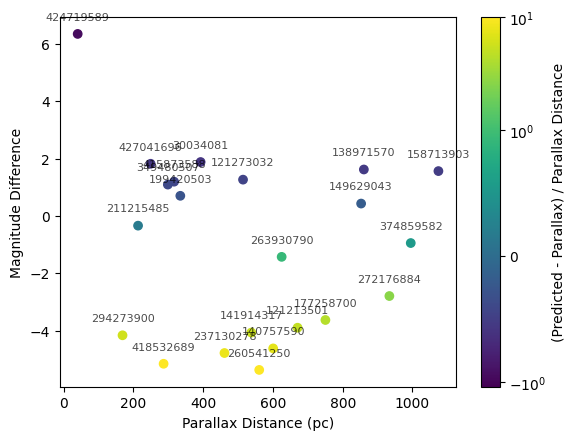

2.5551280636138394
0.3590927117253665


In [20]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors

plt.scatter(df['Dist'], df['diff'], c=((df['calc_d'] - df['Dist'])/df['Dist']), norm=colors.SymLogNorm(linthresh=1, linscale=1, 
                                           vmin=-1.1, vmax=10))
cbar = plt.colorbar()
cbar.ax.set_ylabel('(Predicted - Parallax) / Parallax Distance')
plt.xlabel('Parallax Distance (pc)')
plt.ylabel('Magnitude Difference')

for i, row in df.iterrows():
    plt.annotate(
        row['Target'],                      # The text to display
        (row['Dist'], row['diff']),         # Coordinates of the point
        textcoords="offset points",         # How to position the text
        xytext=(0, 10),                     # Distance from text to point (x,y)
        ha='center',                        # Horizontal alignment
        fontsize=8,                         # Smaller font for readability
        alpha=0.7                           # Slight transparency
    )

# plt.ylim(-5, 6)
plt.show()

print(((df['calc_d'] - df['Dist'])/df['Dist']).mean())
print(((df['calc_d'] - df['Dist'])/df['Dist']).median())

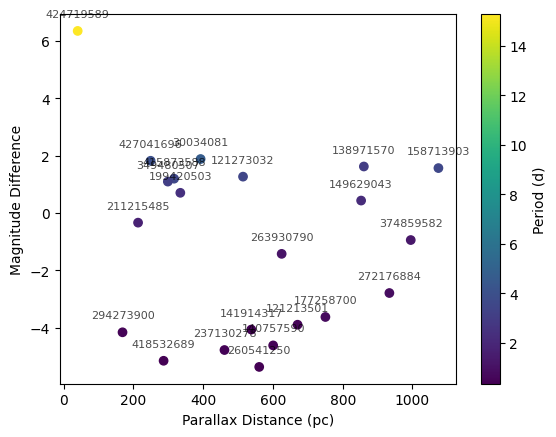

In [21]:
plt.scatter(df['Dist'], df['diff'], c=(df['Period']))
cbar = plt.colorbar()
cbar.ax.set_ylabel('Period (d)')
plt.xlabel('Parallax Distance (pc)')
plt.ylabel('Magnitude Difference')

for i, row in df.iterrows():
    plt.annotate(
        row['Target'],                      # The text to display
        (row['Dist'], row['diff']),         # Coordinates of the point
        textcoords="offset points",         # How to position the text
        xytext=(0, 10),                     # Distance from text to point (x,y)
        ha='center',                        # Horizontal alignment
        fontsize=8,                         # Smaller font for readability
        alpha=0.7                           # Slight transparency
    )

plt.show()

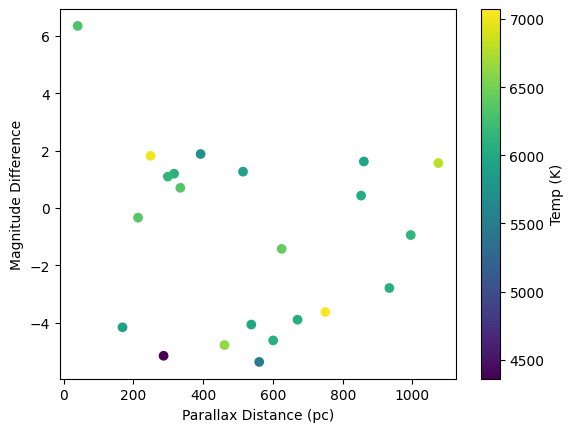

In [22]:
plt.scatter(df['Dist'], df['diff'], c=(df['Ballesteros T']))
cbar = plt.colorbar()
cbar.ax.set_ylabel('Temp (K)')
plt.xlabel('Parallax Distance (pc)')
plt.ylabel('Magnitude Difference')
plt.show()

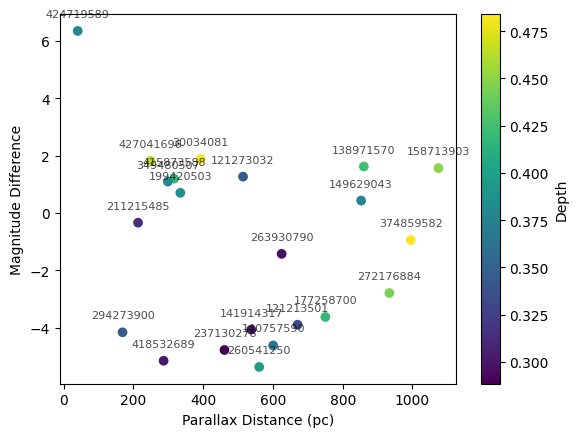

In [17]:
plt.scatter(df['Dist'][df['depth'] <= 0.5], df['diff'][df['depth'] <= 0.5], c=(df['depth'][df['depth'] <= 0.5]))
cbar = plt.colorbar()
cbar.ax.set_ylabel('Depth')
plt.xlabel('Parallax Distance (pc)')
plt.ylabel('Magnitude Difference')

for i, row in df[df['depth'] < 0.5].iterrows():
    plt.annotate(
        row['Target'],                      # The text to display
        (row['Dist'], row['diff']),         # Coordinates of the point
        textcoords="offset points",         # How to position the text
        xytext=(0, 10),                     # Distance from text to point (x,y)
        ha='center',                        # Horizontal alignment
        fontsize=8,                         # Smaller font for readability
        alpha=0.7                           # Slight transparency
    )

plt.show()